# qsim autocalib: Rabi / Ramsey / DRAG

This notebook keeps only experiment-level code. The workflow execution, temporary config generation, and heterodyne I/Q integration statistics are handled by `qsim.ui.notebook` helpers.

Config layout:
- shared device: `device.yaml`
- Rabi: `rabi/task.yaml`, `rabi/solver.yaml`, `rabi/pulse.yaml`, `rabi/analyser.yaml`
- Ramsey: `ramsey/task.yaml`, `ramsey/solver.yaml`, `ramsey/pulse.yaml`, `ramsey/analyser.yaml`
- DRAG: `drag/task.yaml`, `drag/solver.yaml`, `drag/pulse.yaml`, `drag/analyser.yaml`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src" / "qsim").exists():
    ROOT = next((p for p in Path.cwd().parents if (p / "src" / "qsim").exists()), Path.cwd())
sys.path.insert(0, str(ROOT / "src"))

from qsim.ui.notebook import (
    integrated_heterodyne_iq,
    integrated_iq_mean_error,
    plot_iq_cloud,
    plot_iq_clouds,
    run_param_sweep,
    run_pulse_sweep,
)

BASE = ROOT / "autocalib"
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "axes.grid": True})

## Rabi

In [6]:
from qsim.workflow import create_model

TASK_DIR = Path("rabi")
model = create_model(task_config=TASK_DIR / 'task.yaml')
model.run_all()

10.0%. Run time:   0.40s. Est. time left: 00:00:00:03
20.0%. Run time:   0.82s. Est. time left: 00:00:00:03
30.0%. Run time:   1.27s. Est. time left: 00:00:00:02
40.0%. Run time:   1.68s. Est. time left: 00:00:00:02
50.0%. Run time:   2.08s. Est. time left: 00:00:00:02
60.0%. Run time:   2.46s. Est. time left: 00:00:00:01
70.0%. Run time:   2.87s. Est. time left: 00:00:00:01
80.0%. Run time:   3.26s. Est. time left: 00:00:00:00
90.0%. Run time:   3.66s. Est. time left: 00:00:00:00
100.0%. Run time:   4.06s. Est. time left: 00:00:00:00
Total run time:   4.09s


In [27]:
model.results.trajectories['solver_0'].measurements['records'][0]['heterodyne_I']

[0.0,
 6096.637323207552,
 6062.718276402027,
 10898.501223562902,
 -20266.272473572895,
 1173.988051709497,
 15186.42250429079,
 13133.66623276583,
 15273.847318424036,
 -7879.287919667281,
 -24514.68189415078,
 -31647.96568394095,
 -35384.1353408071,
 55295.171636145154,
 4382.119343198922,
 44202.65072846614,
 -8017.18251525609,
 -1589.161240422286,
 17132.436936713588,
 -6103.194331118393,
 -18018.429003700854,
 -32053.775469935663,
 85634.22158480025,
 -51112.273170187196,
 10116.127829092215,
 -23784.173504086662,
 -16108.742006694516,
 22023.668011945778,
 26431.75941266661,
 -63207.20990487025,
 1507.2852774468704,
 -1250.7027058309477,
 -14018.011575425538,
 -17301.783969867887,
 19241.864466930092,
 -59136.45048780359,
 -20744.398392675317,
 6599.663837546331,
 17969.897975878375,
 9249.432415316965,
 -28625.16722527005,
 4822.200398798224,
 1574.4274511849853,
 25751.352092913672,
 97513.945317627,
 9591.271071806319,
 -9715.989683348216,
 19408.617471265134,
 63.22407843040

10.0%. Run time:   0.33s. Est. time left: 00:00:00:02
20.0%. Run time:   0.73s. Est. time left: 00:00:00:02
30.0%. Run time:   1.14s. Est. time left: 00:00:00:02
40.0%. Run time:   1.58s. Est. time left: 00:00:00:02
50.0%. Run time:   1.93s. Est. time left: 00:00:00:01
60.0%. Run time:   2.29s. Est. time left: 00:00:00:01
70.0%. Run time:   2.67s. Est. time left: 00:00:00:01
80.0%. Run time:   3.08s. Est. time left: 00:00:00:00
90.0%. Run time:   3.50s. Est. time left: 00:00:00:00
100.0%. Run time:   3.89s. Est. time left: 00:00:00:00
Total run time:   3.91s
10.0%. Run time:   0.37s. Est. time left: 00:00:00:03
20.0%. Run time:   0.82s. Est. time left: 00:00:00:03
30.0%. Run time:   1.22s. Est. time left: 00:00:00:02
40.0%. Run time:   1.62s. Est. time left: 00:00:00:02
50.0%. Run time:   2.08s. Est. time left: 00:00:00:02
60.0%. Run time:   2.55s. Est. time left: 00:00:00:01
70.0%. Run time:   2.95s. Est. time left: 00:00:00:01
80.0%. Run time:   3.37s. Est. time left: 00:00:00:00
90.

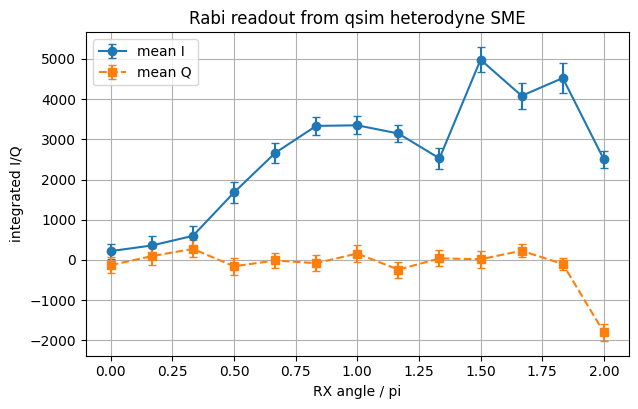

In [5]:
rabi_thetas = np.linspace(0.0, 2.0 * np.pi, 13)
rabi_cases = run_param_sweep(
    BASE / "rabi" / "task.yaml",
    "theta",
    rabi_thetas,
    generated_dir=BASE / "generated_configs" / "rabi",
    out_root=BASE / "runs" / "rabi",
    study_name="rabi_sme",
)

rabi_iq = integrated_iq_mean_error(rabi_cases)
fig, ax = plt.subplots()
ax.errorbar(rabi_thetas / np.pi, rabi_iq["mean"][:, 0], yerr=rabi_iq["error"][:, 0], fmt="o-", capsize=3, label="mean I")
ax.errorbar(rabi_thetas / np.pi, rabi_iq["mean"][:, 1], yerr=rabi_iq["error"][:, 1], fmt="s--", capsize=3, label="mean Q")
ax.set_xlabel("RX angle / pi")
ax.set_ylabel("integrated I/Q")
ax.set_title("Rabi readout from qsim heterodyne SME")
ax.legend();

AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

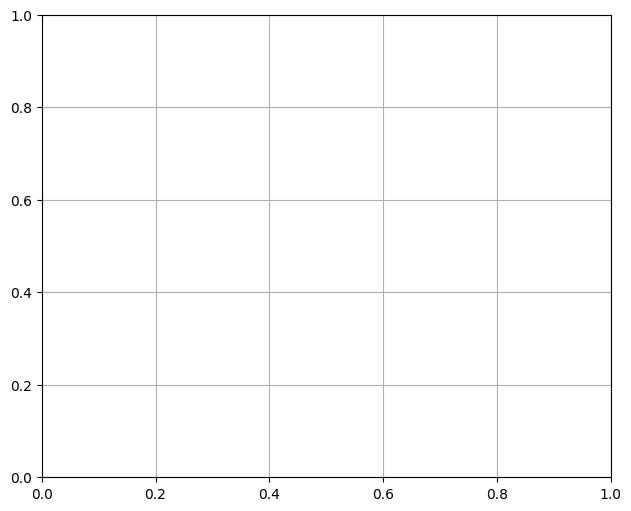

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
plot_iq_clouds(ax, [rabi_cases[idx] for idx in [0, 3, 6]], "Rabi integrated I/Q")

## Ramsey

10.0%. Run time:   0.35s. Est. time left: 00:00:00:03
20.0%. Run time:   0.75s. Est. time left: 00:00:00:02
30.0%. Run time:   1.15s. Est. time left: 00:00:00:02
40.0%. Run time:   1.56s. Est. time left: 00:00:00:02
50.0%. Run time:   2.04s. Est. time left: 00:00:00:02
60.0%. Run time:   2.41s. Est. time left: 00:00:00:01
70.0%. Run time:   2.84s. Est. time left: 00:00:00:01
80.0%. Run time:   3.34s. Est. time left: 00:00:00:00
90.0%. Run time:   3.73s. Est. time left: 00:00:00:00
100.0%. Run time:   4.16s. Est. time left: 00:00:00:00
Total run time:   4.18s
10.0%. Run time:   0.38s. Est. time left: 00:00:00:03
20.0%. Run time:   0.87s. Est. time left: 00:00:00:03
30.0%. Run time:   1.32s. Est. time left: 00:00:00:03
40.0%. Run time:   1.72s. Est. time left: 00:00:00:02
50.0%. Run time:   2.13s. Est. time left: 00:00:00:02
60.0%. Run time:   2.57s. Est. time left: 00:00:00:01
70.0%. Run time:   2.97s. Est. time left: 00:00:00:01
80.0%. Run time:   3.40s. Est. time left: 00:00:00:00
90.

d:\超导量子计算机噪声抑制\qsim\src\qsim\ui\notebook.py:330: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(points, axis=0)
c:\Users\yijia\anaconda3\envs\qsim\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


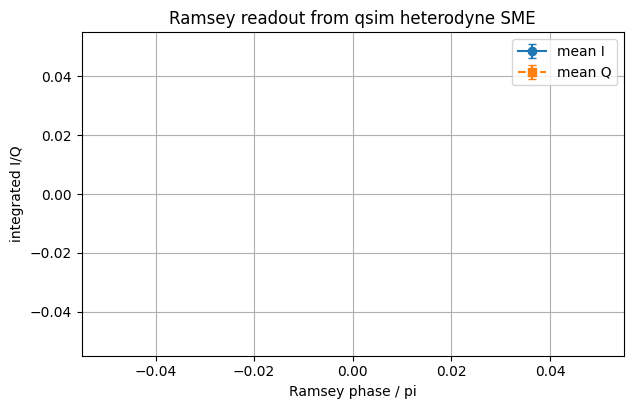

In [4]:
ramsey_phis = np.linspace(0.0, 2.0 * np.pi, 13)
ramsey_cases = run_param_sweep(
    BASE / "ramsey" / "task.yaml",
    "phi",
    ramsey_phis,
    generated_dir=BASE / "generated_configs" / "ramsey",
    out_root=BASE / "runs" / "ramsey",
    study_name="ramsey_sme",
)

ramsey_iq = integrated_iq_mean_error(ramsey_cases)
fig, ax = plt.subplots()
ax.errorbar(ramsey_phis / np.pi, ramsey_iq["mean"][:, 0], yerr=ramsey_iq["error"][:, 0], fmt="o-", capsize=3, label="mean I")
ax.errorbar(ramsey_phis / np.pi, ramsey_iq["mean"][:, 1], yerr=ramsey_iq["error"][:, 1], fmt="s--", capsize=3, label="mean Q")
ax.set_xlabel("Ramsey phase / pi")
ax.set_ylabel("integrated I/Q")
ax.set_title("Ramsey readout from qsim heterodyne SME")
ax.legend();

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
plot_iq_clouds(ax, [ramsey_cases[idx] for idx in [0, len(ramsey_cases) // 2, -1]], "Ramsey integrated I/Q")

## DRAG

In [ ]:
drag_betas = np.linspace(-1.0, 1.0, 11)
drag_cases = run_pulse_sweep(
    BASE / "drag" / "task.yaml",
    "single_qubit_drag_beta",
    drag_betas,
    generated_dir=BASE / "generated_configs" / "drag",
    out_root=BASE / "runs" / "drag",
    study_name="drag_sme",
)

drag_iq = integrated_iq_mean_error(drag_cases)
best_idx = int(np.nanargmax(np.linalg.norm(drag_iq["mean"], axis=1)))
fig, ax = plt.subplots()
ax.errorbar(drag_betas, drag_iq["mean"][:, 0], yerr=drag_iq["error"][:, 0], fmt="o-", capsize=3, label="mean I")
ax.errorbar(drag_betas, drag_iq["mean"][:, 1], yerr=drag_iq["error"][:, 1], fmt="s--", capsize=3, label="mean Q")
ax.axvline(drag_betas[best_idx], color="black", lw=1.0, alpha=0.6)
ax.set_xlabel("DRAG beta")
ax.set_ylabel("integrated I/Q")
ax.set_title("DRAG readout from qsim heterodyne SME")
ax.legend();
print(f"largest readout response beta={drag_betas[best_idx]:.3f}, shots={drag_iq['n'][best_idx]}")

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
plot_iq_clouds(ax, [drag_cases[idx] for idx in [0, best_idx, -1]], "DRAG integrated I/Q")

## Payload check

In [ ]:
sample = drag_cases[best_idx]
tr = sample["trajectory"]
print("output dir:", sample["out_dir"])
print("engine:", tr.engine)
print("solver_impl:", tr.metadata.get("solver_impl"))
print("readout_protocol:", tr.metadata.get("readout_protocol"))
print("measurement records:", len((tr.measurements or {}).get("records", [])))
print("integrated I/Q points:", integrated_heterodyne_iq(sample).shape)
stats = integrated_iq_mean_error([sample])
print("integrated I/Q mean:", stats["mean"][0])
print("integrated I/Q errorbar (SEM):", stats["error"][0])